# Class 5 - Geospatial Data (netCDF & xarray)

Recommended documentation: [Geospatial course from UGhent](https://github.com/plovercode/DS-python-geospatial/tree/main/notebooks)


Today we move from **time-series tabular data** (pandas, Class 4) to **multi-dimensional gridded data**.

Goals:
- understand what a netCDF file is and how to read it with  **xarray** ,
- select, slice, reduce, filter, resample gridded temperature data,
- apply value masks and geographic masks (e.g. keep only grid cells inside Freiburg city).

> **Scope of this course:** we mainly work with **raster / netCDF** data. For geographic masking we load one pre-prepared Boolean mask file (`freiburg_city_mask.nc`).

## 1. From pandas to xarray

In Class 4, each row was one time step and each column was one variable (temperature, humidity, …). That works well for a **point station**.

Gridded climate data has more axes at once, for example:

- **time** (hourly steps in January 2024),
- **latitude**,
- **longitude**,
- and one or more **data variables** (here: predicted temperature).

![xarray Dataset: data variables, coordinates, and attributes](img/xarray-dataset.png)

*Figure: an `xarray.Dataset` can hold several data variables that share coordinates (e.g. lon, lat, time), plus metadata in attributes. (Source: [xarray documentation](https://docs.xarray.dev/).)*


In [2]:
# Running this cell can take a few minutes
import matplotlib.pyplot as plt
import xarray as xr

## 2. Opening a netCDF with xarray

We use Future Forests **predicted 2 m air temperature** (`pred_temperature_C`) for January 2024 on a ~100 m grid provided by Christopher Jung.

The raw file is stored in projected coordinates (EPSG:25832, ETRS89 / UTM zone 32N). For class, we use a **preprocessed lon/lat (WGS84)** version:

In [3]:
ls ../processed_data/pred_temperature_C_2024_01_wgs84.nc

../processed_data/pred_temperature_C_2024_01_wgs84.nc


`xr.open_dataset` reads the file and returns a **Dataset**: a dictionary-like container of labelled arrays (DataArrays) that share dimensions.

In [4]:
DataPath = "../processed_data/pred_temperature_C_2024_01_wgs84.nc"
# Lazy open: do not load the full ~3 GB grid into memory at once
TempDs = xr.open_dataset(DataPath, chunks="auto") # chunks="auto" open the files in chunks
print(TempDs)

<xarray.Dataset> Size: 11GB
Dimensions:             (time: 744, lat: 2132, lon: 1701)
Coordinates:
  * time                (time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T2...
  * lat                 (lat) float64 17kB 49.65 49.65 49.65 ... 47.48 47.48
  * lon                 (lon) float64 14kB 7.311 7.312 7.313 ... 9.042 9.043
Data variables:
    pred_temperature_C  (time, lat, lon) float32 11GB dask.array<chunksize=(166, 474, 378), meta=np.ndarray>
    crs                 int64 8B ...
Attributes: (12/13)
    Conventions:            CF-1.8
    title:                  Predicted temperature on 100 m grid (reprojected ...
    source_file:            ["D:\\ERA5\\Future_Forests_Area\\d2m_C\\ERA5_2024...
    model_features:         ["Albedo_Albedo", "Albedo_Multiscale_Features_Alb...
    baseline_feature:       t2m_C
    baseline_scale_factor:  0.1
    ...                     ...
    institution:            Future Forests
    references:             LightGBM model application
    commen

On the output above we can observe:
1. There are 3 dimensions which are the 3 coordinates; `time` of size 744 (why?), `lat` of size 2132 and `lon` of size 1701.
2. There are two data variables, but only one is usuable (`crs` is for metadata): `pred_temperature_C` of shape `(time, lat, lon)`

Let's select the variable that interests us (there is only one variable in this file but there could be multiple):

In [5]:
Temp = TempDs["pred_temperature_C"]
print(Temp.dims)

('time', 'lat', 'lon')


`Temp` is a **`DataArray`**, an array of one variable (unlike the **`Dataset`**, which can hold several variables at once) with its own **dimension names** (`time`, `lat`, `lon`), **coordinate arrays** (`Temp.time`, `Temp.lat`, `Temp.lon`) and many other "**methods**" like `.dims`.

## 3. Selecting data

Similarly to `pandas`, there are two ways to select and slice data with `xarray`:

1. **`.isel(...)`** select by **integer position** (like NumPy indexing)

In [6]:
# Position-based: first time step
FirstMap = Temp.isel(time=0)

Quick map of the first time step with matplotlib. For a **2D grid** (lon × lat), use `plt.pcolormesh` to colour each cell

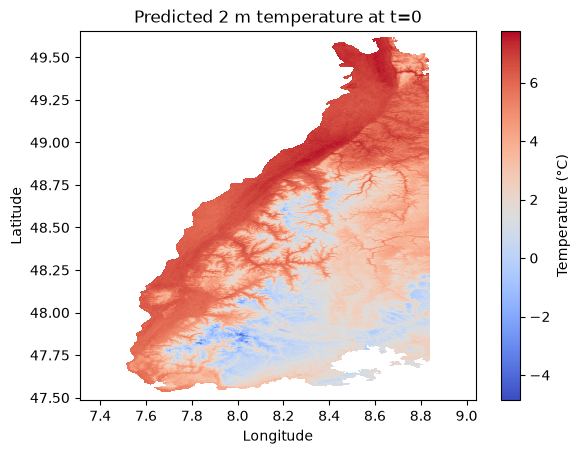

In [7]:
plt.pcolormesh(FirstMap.lon, FirstMap.lat, FirstMap, cmap="coolwarm", shading="auto")
# cmap = colormap (colour scale for the data values)
# shading = how the rectangular grid cells are rendered ("auto" infers it from lon/lat/data shapes)
# Always check the docs of each function you are using!
plt.colorbar(label="Temperature (°C)")
plt.title("Predicted 2 m temperature at t=0")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

- **`.sel(...)`** select by **coordinate label** (like pandas `.loc`)

In **Class 4** you worked with hourly data from the **Hartheim** climate station. We can extract the same location from the gridded map (~7.60°E, 47.93°N). The model grid will not contain that exact lon/lat pair, so we use `method="nearest"` to snap to the closest grid cell:

In [8]:
# Label-based: temperature near Hartheim station (~7.60°E, 47.93°N)
HartheimLon, HartheimLat = 7.60, 47.93
HartheimSeries = Temp.sel(lon=HartheimLon, lat=HartheimLat, method="nearest") # Nearest is used here for inexact matches

## Exercise A

Try to make a figure (which one will suit the most?) of `HartheimSeries`

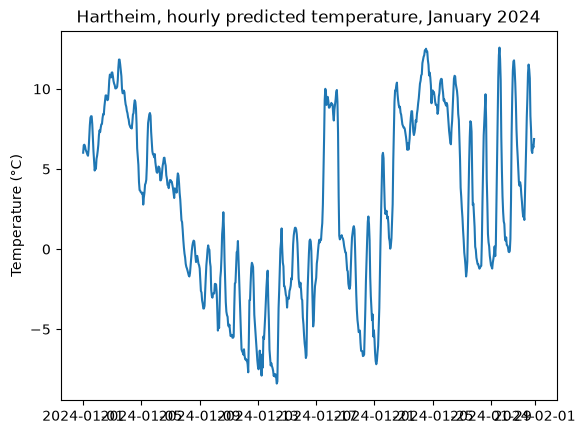

In [9]:
# Solution
plt.plot(HartheimSeries.time, HartheimSeries)
plt.ylabel("Temperature (°C)")
plt.title("Hartheim, hourly predicted temperature, January 2024")
plt.show()

## 4. Slicing data

So far we selected a **single** time step (`.isel`) or a **single** grid point (`.sel` with `method="nearest"`). Often you want a **sub-region**: a box in lon/lat, or a time window.

Inside `.sel(...)`, pass Python's built-in `slice(start, stop)` for ranges, the same idea as `df.loc['2024-01-01':'2024-01-07']` in pandas:

- `slice(7.5, 8.1)` on `lon` keeps all cells between 7.5°E and 8.1°E
- `slice(48.15, 47.75)` on `lat` keeps all cells between 48.15°N and 47.75°N

The result is still a `DataArray`, but smaller: it keeps every time step inside the box.

Frozen({'time': 744, 'lat': 2132, 'lon': 1701})
Frozen({'time': 744, 'lat': 392, 'lon': 589})


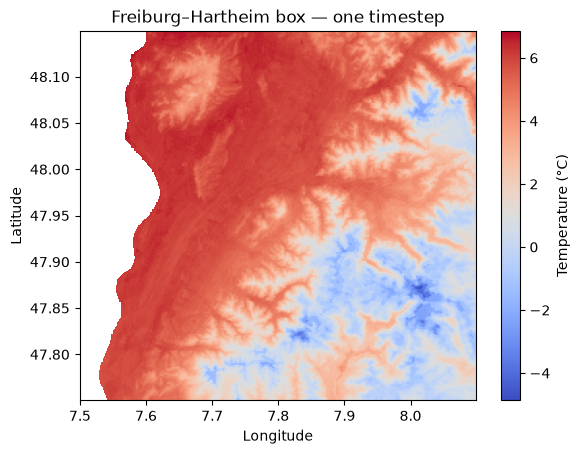

In [10]:
# Small box around Freiburg / Hartheim
print(Temp.sizes)
FreiburgBox = Temp.sel(
    lon=slice(7.5, 8.1),
    lat=slice(48.15, 47.75),  # high → low if lat decreases with index
)
print(FreiburgBox.sizes)

BoxMap = FreiburgBox.isel(time=0)

plt.pcolormesh(BoxMap.lon, BoxMap.lat, BoxMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Freiburg–Hartheim box — one timestep")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

> **Note:** for latitude, values decrease north to south, this is not always the case.


## 5. Reduction

Let's say you want a map of the January temperature average. You have hourly values at every grid cell, so you need to collapse the time dimension and keep the spatial ones.

Reductions such as `.mean()`, `.min()`, `.max()` can run along one dimension. It is the same idea as pandas aggregations, but you name the axis explicitly.

In [11]:
JanMeanMap = Temp.mean(dim="time")
print(JanMeanMap.dims)

('lat', 'lon')


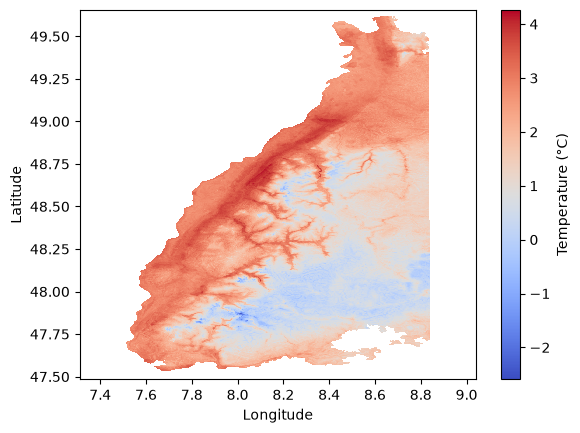

In [12]:
plt.pcolormesh(JanMeanMap.lon, JanMeanMap.lat, JanMeanMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Now ask how the region as a whole evolved during January. This time you collapse lat and lon and keep time, which leaves you with a single time series instead of a map.

In [13]:
# Spatial mean over the Freiburg box → one value per time
BoxSpatialMean = FreiburgBox.mean(dim=("lat", "lon"))
print(BoxSpatialMean.dims)

('time',)


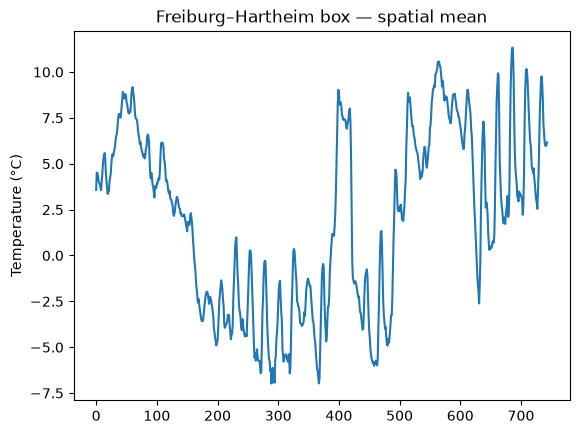

In [14]:
plt.plot(BoxSpatialMean)
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — spatial mean")
plt.show()

## Exercise B

Similarly to what we have done above, try to reduce the right dimension to make a zonal mean (or latitudinal) plot with `FreiburgBox`

('lat',)


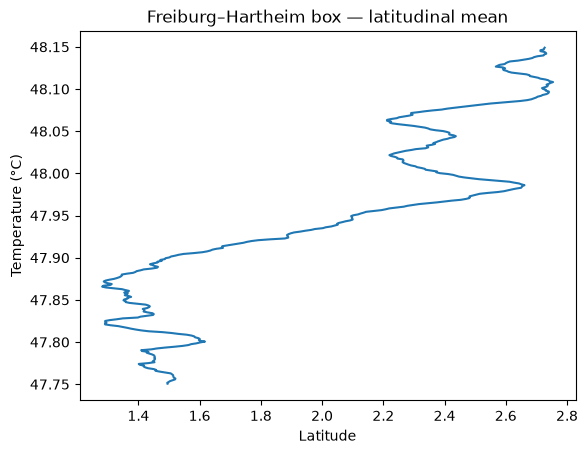

In [15]:
# Solution
BoxLatitudinalMean = FreiburgBox.mean(dim=("lon", "time"))
print(BoxLatitudinalMean.dims)

plt.plot(BoxLatitudinalMean, BoxLatitudinalMean.lat)
plt.xlabel("Latitude")
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — latitudinal mean")
plt.show()

## 6. Changing time resolution (`resample`)

In **Class 4**, you used `.resample('D').mean()` on the Hartheim station table to go from hourly to daily values. `xarray` does the same on gridded data: group timestamps into coarser bins, then aggregate, e.g. **`resample(time="1D")`:** calendar-day bins (then `.mean()`, `.sum()`, …)

The frequency strings differ slightly from pandas (`"1D"` vs `"D"`), but the idea is unchanged: **change the time resolution, then reduce**.


('time',)


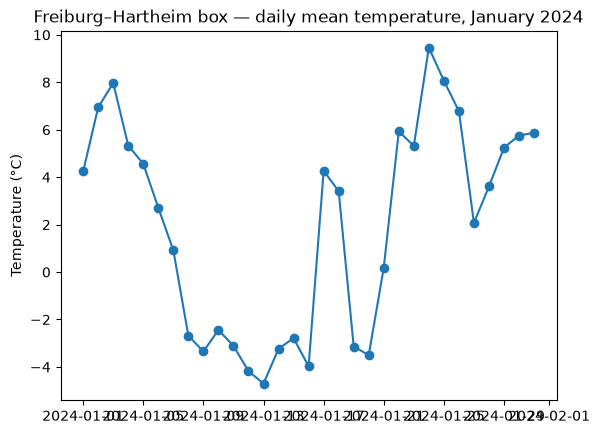

In [ ]:
# Daily means: spatial mean over the box, then change time resolution
BoxSeries = FreiburgBox.mean(dim=("lat", "lon"))
Daily = BoxSeries.resample(time="1D").mean()

plt.plot(Daily.time, Daily, marker="o")
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — daily mean temperature, January 2024")
plt.show()

## 7. Filtering / masking with `.where`

In **Class 3b**, you filtered NumPy arrays with a Boolean mask, e.g. `TempC[TempC > 21.0]`. That keeps only the matching values and **shrinks** the array.

When you need the **same shape** as the input, for example to plot a map where rejected cells are blank, you used `np.where(condition, value_if_true, np.nan)`.

xarray's `.where(condition)` does the same thing on a `DataArray`: it keeps values where the condition is `True` and sets the rest to `NaN` (grid shape unchanged — useful for maps).


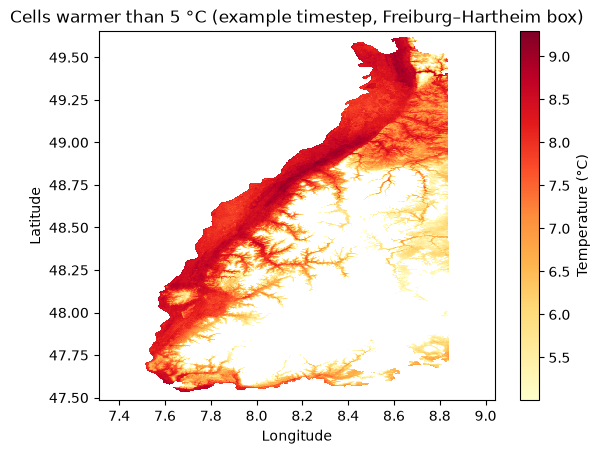

In [17]:
WarmCells = Temp.where(Temp > 5)
WarmMap = WarmCells.isel(time=12)

plt.pcolormesh(WarmMap.lon, WarmMap.lat, WarmMap, cmap="YlOrRd", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Cells warmer than 5 °C (example timestep, Freiburg–Hartheim box)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Geographic masks

The example above used a **value mask** (`Temp > 5`): a field of `True`/`False` values, like the Boolean masks in **Class 4**.

You can also mask by **location**. For Freiburg city, we prepared a Boolean mask on the same lon/lat grid (`freiburg_city_mask.nc` in `processed_data/`, built from the OpenStreetMap city boundary). Load it with `xr.open_dataarray`, then pass it to `.where(...)` — same pattern as before, but the condition comes from a file instead of `Temp > 5`.

The same idea works with **elevation**: `elevation_m_wgs84.nc` gives terrain height (m) on the same grid (Exercise E).

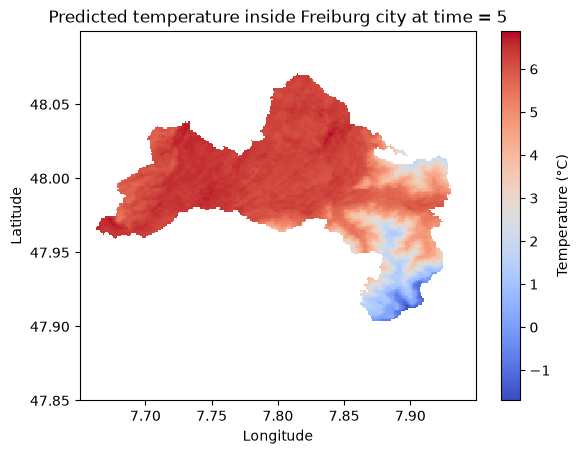

In [18]:
InFreiburg = xr.open_dataarray("../processed_data/freiburg_city_mask.nc")

# Zoom in on the city
LocalBox = Temp.sel(lon=slice(7.65, 7.95), lat=slice(48.1, 47.85))

# Masking
LocalBoxMasked = LocalBox.where(InFreiburg)

# Select time-step
CityMap = LocalBoxMasked.isel(time=5)

plt.pcolormesh(CityMap.lon, CityMap.lat, CityMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Predicted temperature inside Freiburg city at time = 5")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Exercise C

Foresters are going to cut trees on a specific region (`lon=7.5–8.1`, `lat=48.15→47.75`), on a specific date (`2024-01-20T14:00`). They ask you to make a map of the area that are frozen (where they cannot use their tools).

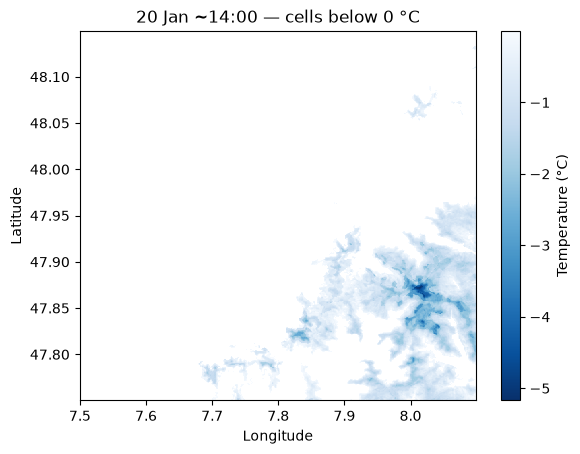

In [19]:
# Solution
CollectWoodDate = Temp.sel(lon=slice(7.5, 8.1), lat=slice(48.15, 47.75)).sel(
    time="2024-01-20T14:00", method="nearest"
)
BelowZero = CollectWoodDate.where(CollectWoodDate < 0)

plt.pcolormesh(BelowZero.lon, BelowZero.lat, BelowZero, cmap="Blues_r", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("20 Jan ~14:00 — cells below 0 °C")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


## Exercise D

City trees are known to leaf out earlier and to suffer more summer drought stress than the same species a few kilometres outside, and one suspected reason is that cities are warmer than their surroundings. Warmer winters also matter for forest health: they let insect pests overwinter more successfully.

You have a Boolean mask of Freiburg city (`InFreiburg`) on the same grid, so you can compare the city with the countryside around it. 

Tasks:

1. Build two hourly time series: the spatial mean **inside** the city, and the spatial mean **outside** the city (tip: instead of `.where(InFreiburg)`, use `.where(InFreiburg == False)`). Plot the two series as **daily means** on the same figure, with a legend.

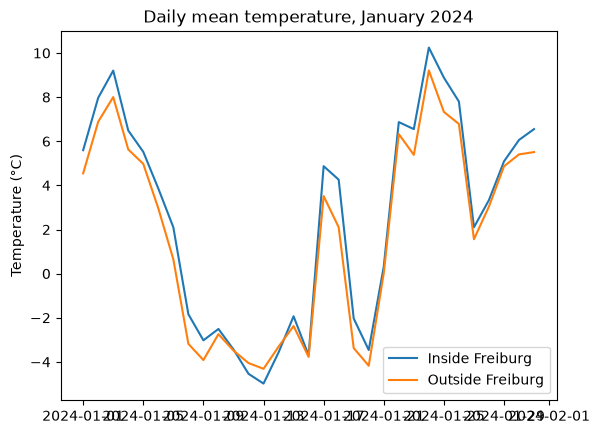

In [20]:
# Solution

InFreiburg = xr.open_dataarray("../processed_data/freiburg_city_mask.nc")
LocalBox = Temp#.sel(lon=slice(7.65, 7.95), lat=slice(48.1, 47.85))

CityOnly = LocalBox.where(InFreiburg)
CitySeries = CityOnly.mean(dim=("lat", "lon"))

RuralOnly = LocalBox.where(InFreiburg == False)
RuralSeries = RuralOnly.mean(dim=("lat", "lon"))

CityDaily = CitySeries.resample(time="1D").mean()
RuralDaily = RuralSeries.resample(time="1D").mean()

plt.plot(CityDaily.time, CityDaily, label="Inside Freiburg")
plt.plot(RuralDaily.time, RuralDaily, label="Outside Freiburg")
plt.ylabel("Temperature (°C)")
plt.title("Daily mean temperature, January 2024")
plt.legend()
plt.show()

3. Compute the hourly difference (city − countryside), plot it, and add a horizontal line at 0 °C (`plt.axhline`)

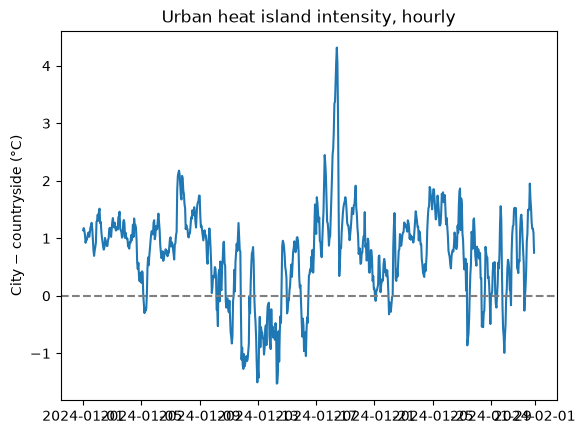

In [21]:
# Solution
DiffSeries = CitySeries - RuralSeries

plt.plot(DiffSeries.time, DiffSeries)
plt.axhline(0, color="grey", linestyle="--")
plt.ylabel("City − countryside (°C)")
plt.title("Urban heat island intensity, hourly")
plt.show()

4. Count the number of hours during which the city was "significantly" warmer than its surroundings (difference is above 1°C). How much % of hours is it for the full month of January?

In [22]:
# Solution
SignDiff = DiffSeries > 1

NHours = int(SignDiff.sum())
TotalHours = SignDiff.size
PctHours = 100 * NHours / TotalHours

print("Hours with differece > 1 °C:",NHours)
print("Share of January hours: (in %)",PctHours)

Hours with differece > 1 °C: 305
Share of January hours: (in %) 40.994623655913976


## Exercise E (Bonus)

On clear winter nights, cold air sinks and pools in valleys. The air layer near the ground can become codler than the air higher up, i.e. a **temperature inversion**. Fog often fills the Rhine valley while the Black Forest ridges (e.g. Schauinsland, ~1 280 m) stay clear and can feel warmer. Locals sometimes say they are “above the fog”.

We prepared a DEM on the same lon/lat grid: `elevation_m_wgs84.nc` in `processed_data/`. Work in the Freiburg box (`lon=7.6, 8.1`, `lat=48.15, 47.7`).

1. Load the DEM and make a map of elevation (`cmap="Greys_r"` is a good choice). 

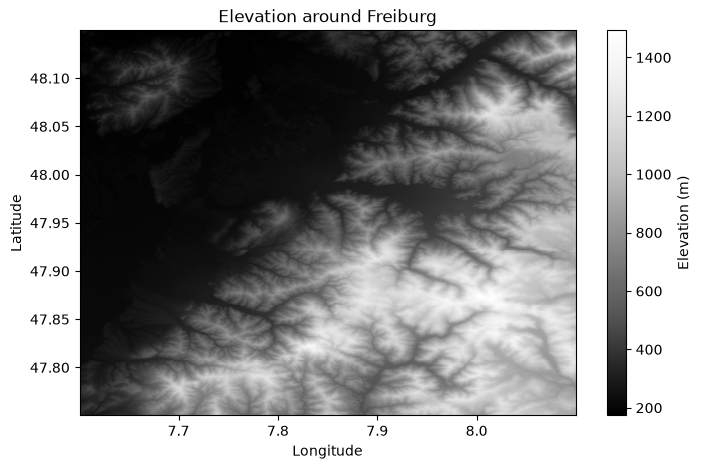

In [37]:
# Solution
Elev = xr.open_dataarray("../processed_data/elevation_m_wgs84.nc")
ElevBox = Elev.sel(lon=slice(7.6, 8.1), lat=slice(48.15, 47.75))

plt.figure(figsize=(8, 5))
plt.pcolormesh(ElevBox.lon, ElevBox.lat, ElevBox, cmap="Greys_r", shading="auto")
plt.colorbar(label="Elevation (m)")
plt.title("Elevation around Freiburg")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

2. Make a single map for valleys (below 600 m) and ridges (above 900 m). You can use two `plt.pcolormesh()` in the same map. 

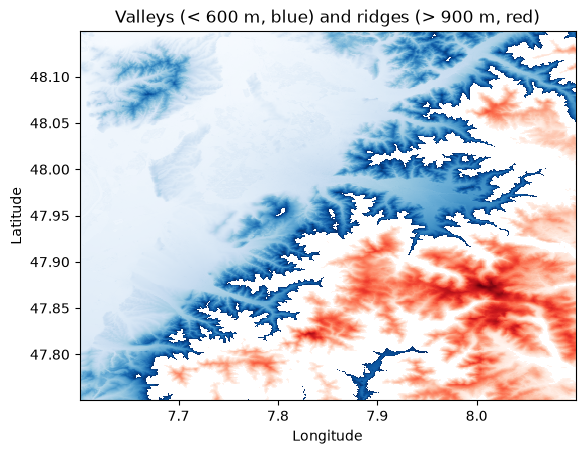

In [51]:
ValleyMask = ElevBox < 600
RidgesMask = ElevBox > 900

ValleyMap = ElevBox.where(ValleyMask)
RidgesMap = ElevBox.where(RidgesMask)

plt.pcolormesh(ValleyMap.lon, ValleyMap.lat, ValleyMap, cmap="Blues", shading="auto")
plt.pcolormesh(RidgesMap.lon, RidgesMap.lat, RidgesMap, cmap="Reds", shading="auto")
plt.title("Valleys (< 600 m, blue) and ridges (> 900 m, red)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

3. Are ridges really warmer than the valley floor? If so, **when**, mainly at night, during the day, or both? Try to produce different plots to help you answer these questions

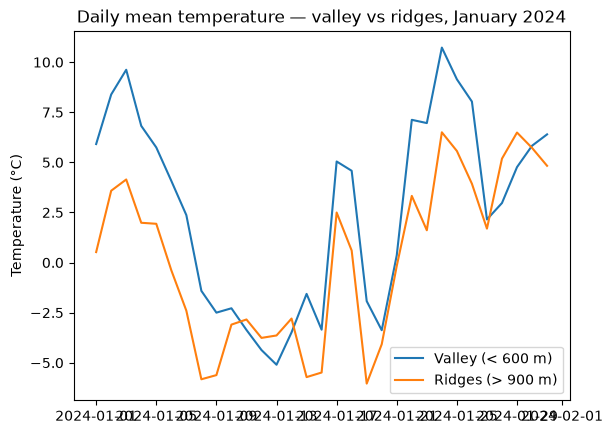

In [54]:
# Solution

FreiburgBox = Temp.sel(lon=slice(7.6, 8.1), lat=slice(48.15, 47.75))

ValleyOnly = FreiburgBox.where(ValleyMask)
ValleySeries = ValleyOnly.mean(dim=("lat", "lon"))

RidgesOnly = FreiburgBox.where(RidgesMask)
RidgesSeries = RidgesOnly.mean(dim=("lat", "lon"))

ValleyDaily = ValleySeries.resample(time="1D").mean()
RidgesDaily = RidgesSeries.resample(time="1D").mean()

plt.plot(ValleyDaily.time, ValleyDaily, label="Valley (< 600 m)")
plt.plot(RidgesDaily.time, RidgesDaily, label="Ridges (> 900 m)")
plt.ylabel("Temperature (°C)")
plt.title("Daily mean temperature — valley vs ridges, January 2024")
plt.legend()
plt.show()

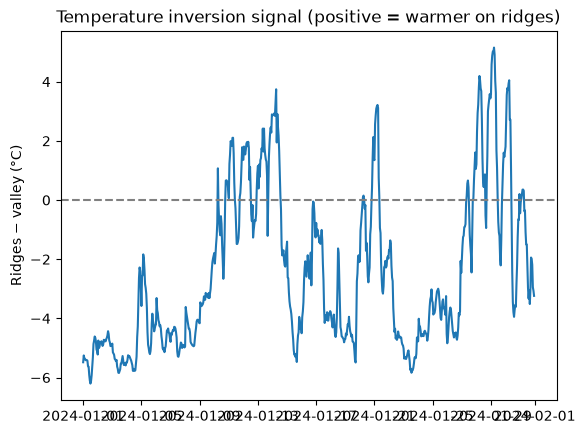

In [55]:
# Solution — 4. Hourly inversion signal (ridges − valley)

DiffSeries = RidgesSeries - ValleySeries

plt.plot(DiffSeries.time, DiffSeries)
plt.axhline(0, color="grey", linestyle="--")
plt.ylabel("Ridges − valley (°C)")
plt.title("Temperature inversion signal (positive = warmer on ridges)")
plt.show()

In [56]:
# Solution — 5. Day vs night inversions

Hour = DiffSeries.time.dt.hour
IsDay = (Hour >= 8) & (Hour <= 18)
IsNight = ~IsDay

Inversion = DiffSeries > 0

NDayInv = int(Inversion.where(IsDay).sum())
NNightInv = int(Inversion.where(IsNight).sum())
NDayHours = int(IsDay.sum())
NNightHours = int(IsNight.sum())

print("Day inversions (08–18 h):", NDayInv, "/", NDayHours, f"({100 * NDayInv / NDayHours:.1f}%)")
print("Night inversions:", NNightInv, "/", NNightHours, f"({100 * NNightInv / NNightHours:.1f}%)")
print("All January:", int(Inversion.sum()), "/", Inversion.size, f"({100 * float(Inversion.mean()):.1f}%)")

Day inversions (08–18 h): 45 / 341 (13.2%)
Night inversions: 110 / 403 (27.3%)
All January: 155 / 744 (20.8%)


**6. Short answer (example):**

On average, ridges are **colder** than the valley (most hourly differences are **below** zero — normal decrease with height). True inversions (ridges warmer than valley) happen in roughly **one fifth** of January hours, mostly **at night** when cold air pools in the valleys. During the day, the sun warms the valley floor and inversions are rarer. So the “warmer on top above the fog” story is real, but **not all the time** — it is mainly a **night-time winter** phenomenon.